In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Data/global_cancer_patients_2015_2024 (1).csv')

In [3]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  str    
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  str    
 3   Country_Region         50000 non-null  str    
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  str    
 11  Cancer_Stage           50000 non-null  str    
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes: float64(8)

In [5]:
df.duplicated().sum()


np.int64(0)

## 2. Age Distribution Analysis

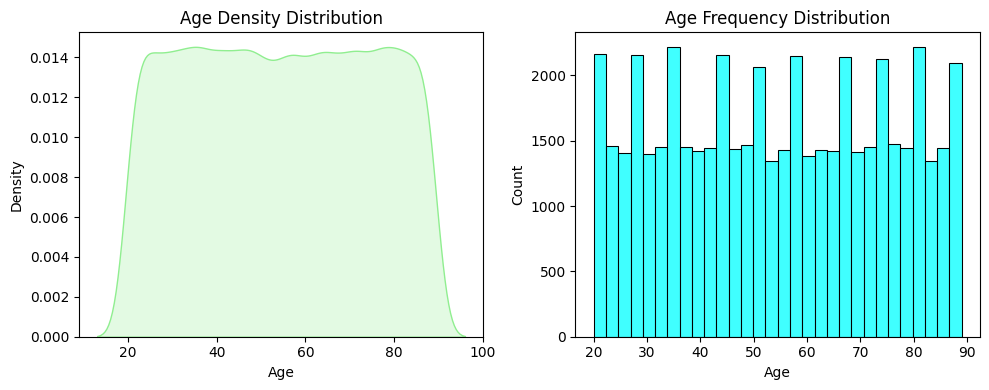

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(df["Age"], fill=True, color="lightgreen")
plt.title("Age Density Distribution")
plt.xlabel("Age")
plt.ylabel("Density")

plt.subplot(1,2,2)
sns.histplot(df["Age"], bins=30,  kde=False, color="cyan")
plt.title("Age Frequency Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()

## 3. Gender Distribution

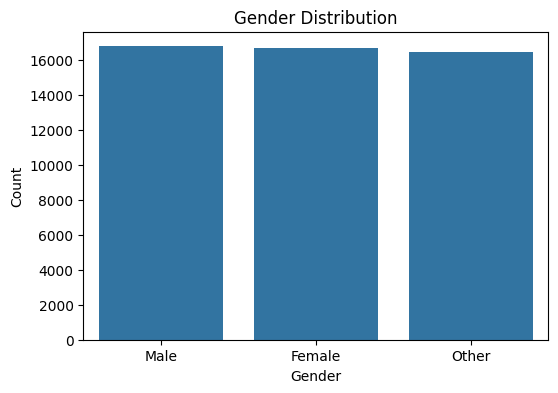

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## 4. Country Distribution 

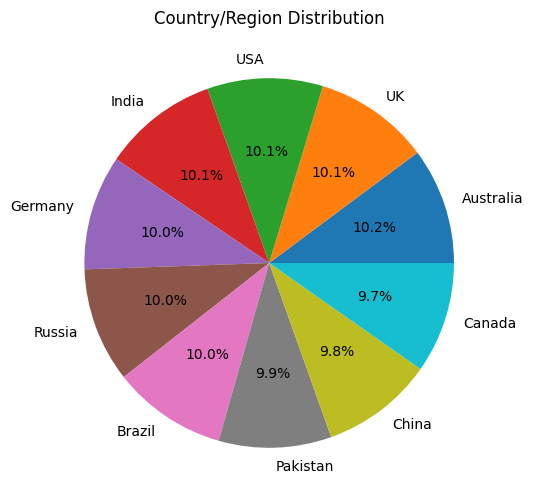

In [8]:
country_counts = df["Country_Region"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(country_counts.values,
        labels=country_counts.index,
        autopct='%1.1f%%')

plt.title("Country/Region Distribution")
plt.show()

## 5. Cancer Type Distribution 

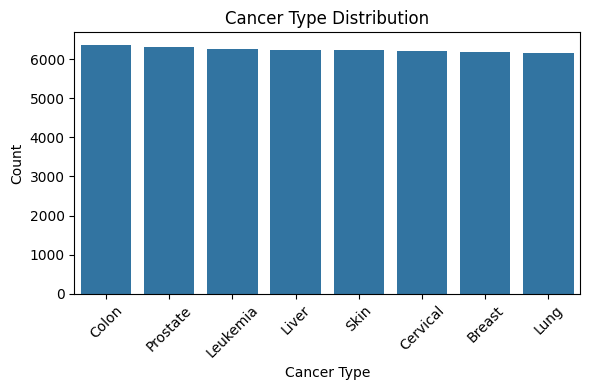

In [9]:
cancer_counts = df["Cancer_Type"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=cancer_counts.index,y=cancer_counts.values)

plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Cancer Stage Distribution

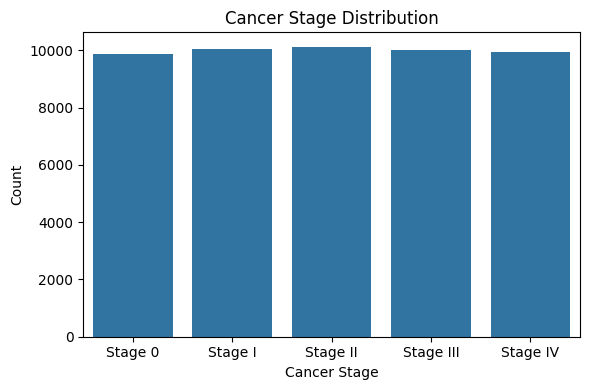

In [10]:
stage_counts = df["Cancer_Stage"].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=stage_counts.index,y=stage_counts.values)

plt.title("Cancer Stage Distribution")
plt.xlabel("Cancer Stage")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 7. Treatment Cost Distribution 

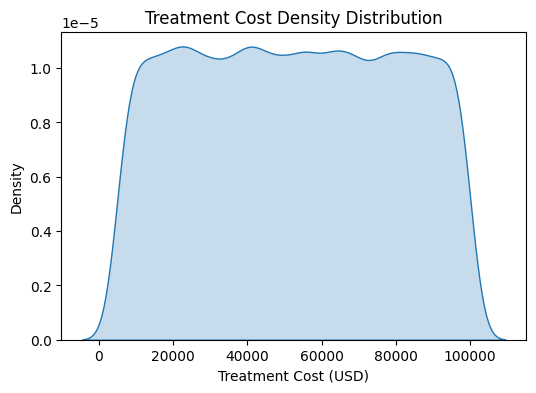

In [11]:
plt.figure(figsize=(6,4))
sns.kdeplot(df["Treatment_Cost_USD"], fill=True)
plt.title("Treatment Cost Density Distribution")
plt.xlabel("Treatment Cost (USD)")
plt.ylabel("Density")
plt.show()


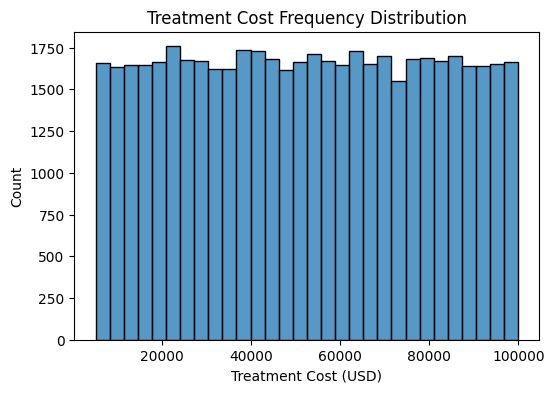

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["Treatment_Cost_USD"], bins=30)
plt.title("Treatment Cost Frequency Distribution")
plt.xlabel("Treatment Cost (USD)")
plt.ylabel("Count")
plt.show()


In [13]:
df["Treatment_Cost_USD"].describe()
df["Treatment_Cost_USD"].skew()

np.float64(0.004063624207520141)

## 8. Risk Factor Summary

In [14]:
column_of_interest = ['Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking','Obesity_Level']
summary = df[column_of_interest].agg(['mean','std','min','max'])

summary

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


## 9. Risk Factors vs Severity (Regression Analysis)

In [15]:
from scipy.stats import linregress

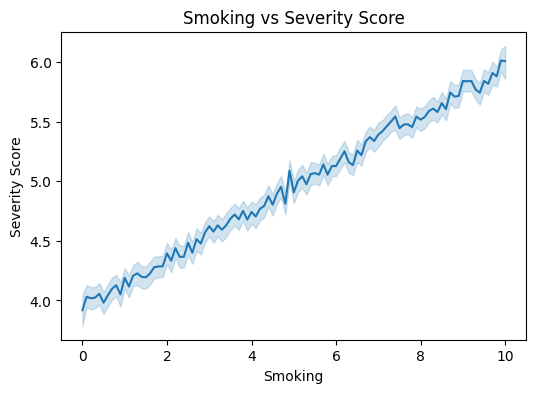

In [16]:
x = df["Smoking"]
y = df["Target_Severity_Score"]

plt.figure(figsize=(6,4))
sns.lineplot(x=x, y=y)
plt.title("Smoking vs Severity Score")
plt.xlabel("Smoking")
plt.ylabel("Severity Score")
plt.show()

In [ ]:
result = linregress(x, y)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-value:", result.rvalue)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)

Slope: 0.20167667746888274
Intercept: 3.944875871172154
R-value: 0.48441983137884825
R-squared: 0.23466257303311178
P-value: 0.0


In [18]:
stage_count = df[df['Cancer_Type'] == 'Lung']['Cancer_Stage'].value_counts()
early_stage_count = stage_count.get('Stage 0',0) + stage_count.get('Stage I',0)
total_sum = stage_count.sum()
(early_stage_count / total_sum)*100

np.float64(38.43156356551388)

In [19]:
cancer_types = df["Cancer_Type"].unique()

for cancer in cancer_types:
    stage_count = df[df["Cancer_Type"] == cancer]["Cancer_Stage"].value_counts()
    early_stage_count = stage_count.get("Stage 0", 0) + stage_count.get("Stage I", 0)
    total_sum = stage_count.sum()
    percentage = (early_stage_count / total_sum) * 100
    print(f"{cancer}: {percentage:.2f}%")

Lung: 38.43%
Leukemia: 39.53%
Breast: 39.47%
Colon: 40.42%
Skin: 40.41%
Cervical: 39.86%
Prostate: 40.19%
Liver: 40.61%


In [20]:
target = ['Age','Genetic_Risk','Air_Pollution',
          'Alcohol_Use','Smoking','Obesity_Level']

y = ['Target_Severity_Score','Survival_Years']
selected_columns = target + y


In [21]:
corr_matrix = df[selected_columns].corr()
corr_matrix

,Age,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Target_Severity_Score,Survival_Years
Age,1.000000,0.002229,0.001101,-0.004130,0.001734,-0.002706,-0.001481,-0.000147
Genetic_Risk,0.002229,1.000000,-0.004492,-0.002558,-0.003718,0.003522,0.478700,0.001708
Air_Pollution,0.001101,-0.004492,1.000000,0.003511,0.003549,0.006507,0.366963,0.000893
Alcohol_Use,-0.004130,-0.002558,0.003511,1.000000,-0.002938,0.007425,0.363250,-0.000527
Smoking,0.001734,-0.003718,0.003549,-0.002938,1.000000,0.005828,0.484420,0.001371
Obesity_Level,-0.002706,0.003522,0.006507,0.007425,0.005828,1.000000,0.251366,0.009771
Target_Severity_Score,-0.001481,0.478700,0.366963,0.363250,0.484420,0.251366,1.000000,0.004161
Survival_Years,-0.000147,0.001708,0.000893,-0.000527,0.001371,0.009771,0.004161,1.000000


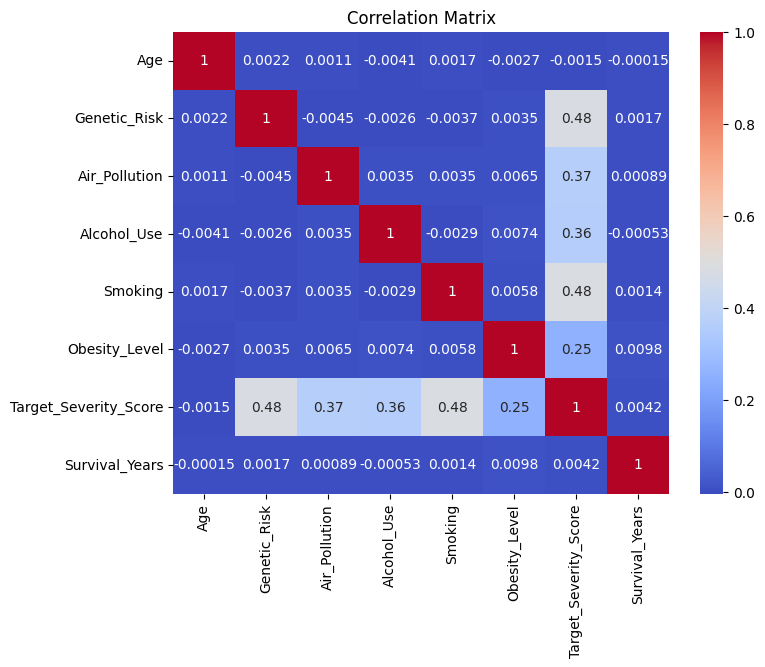

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
